# Task 5 — GRU: Step-by-Step Gating Mechanics

### Introduction
While LSTMs are highly effective at solving the vanishing gradient problem, their 3-gate architecture and separate cell state can be computationally heavy. 

To address this, Kyunghyun Cho et al. introduced the **Gated Recurrent Unit (GRU)** in 2014. The GRU simplifies the recurrent cell structure while maintaining the ability to capture long-range dependencies.

### How GRU Simplifies LSTM:
1. **No separate Cell State**: It maintains only a single hidden state vector $h_t$, which carries both memory and exposed output.
2. **Two Gates**: It merges the forget and input gates into a single **Update Gate** ($z_t$), and introduces a **Reset Gate** ($r_t$).

---

### Step-by-Step Gating Mechanics of the GRU

At each time step $t$, the GRU cell updates its hidden state vector ($h_t$) using the following equations:

#### 1. Reset Gate ($r_t$)
- **Purpose**: Controls how much of the past hidden state ($h_{t-1}$) should be **ignored** when computing the new candidate hidden state.
- **Formula**: $r_t = \sigma(W_r \cdot [h_{t-1}, x_t] + b_r)$
- **Explanation**: A value of `0` means ignore the past context completely (resets the memory), which is useful when transitioning to a new sentence or clause.

#### 2. Update Gate ($z_t$)
- **Purpose**: Acts simultaneously as a forget gate and an input gate. It decides how much of the past hidden state to retain, and how much of the new candidate state to write.
- **Formula**: $z_t = \sigma(W_z \cdot [h_{t-1}, x_t] + b_z)$
- **Explanation**: It acts as a linear interpolator between the past hidden state and the new candidate state.

#### 3. Candidate Hidden State ($\tilde{h}_t$)
- **Purpose**: Computes the proposed new values for the hidden state.
- **Formula**: $\tilde{h}_t = \tanh(W_h \cdot [r_t * h_{t-1}, x_t] + b_h)$
- **Explanation**: The previous hidden state is scaled by the reset gate output ($r_t * h_{t-1}$), then combined with the current input $x_t$ through a $\tanh$ activation.

#### 4. Hidden State Update ($h_t$)
- **Purpose**: Calculates the final hidden state vector at the current time step.
- **Formula**: $h_t = (1 - z_t) * h_{t-1} + z_t * \tilde{h}_t$
- **Explanation**: The update gate $z_t$ acts as a linear blend. If $z_t \approx 1$, we keep the new candidate state $\tilde{h}_t$. If $z_t \approx 0$, we keep the previous hidden state $h_{t-1}$ unchanged.

---

### Conceptual Diagram: GRU Cell
Below is the structural layout of a GRU cell:

![GRU cell](outputs/GRU-cell.png)

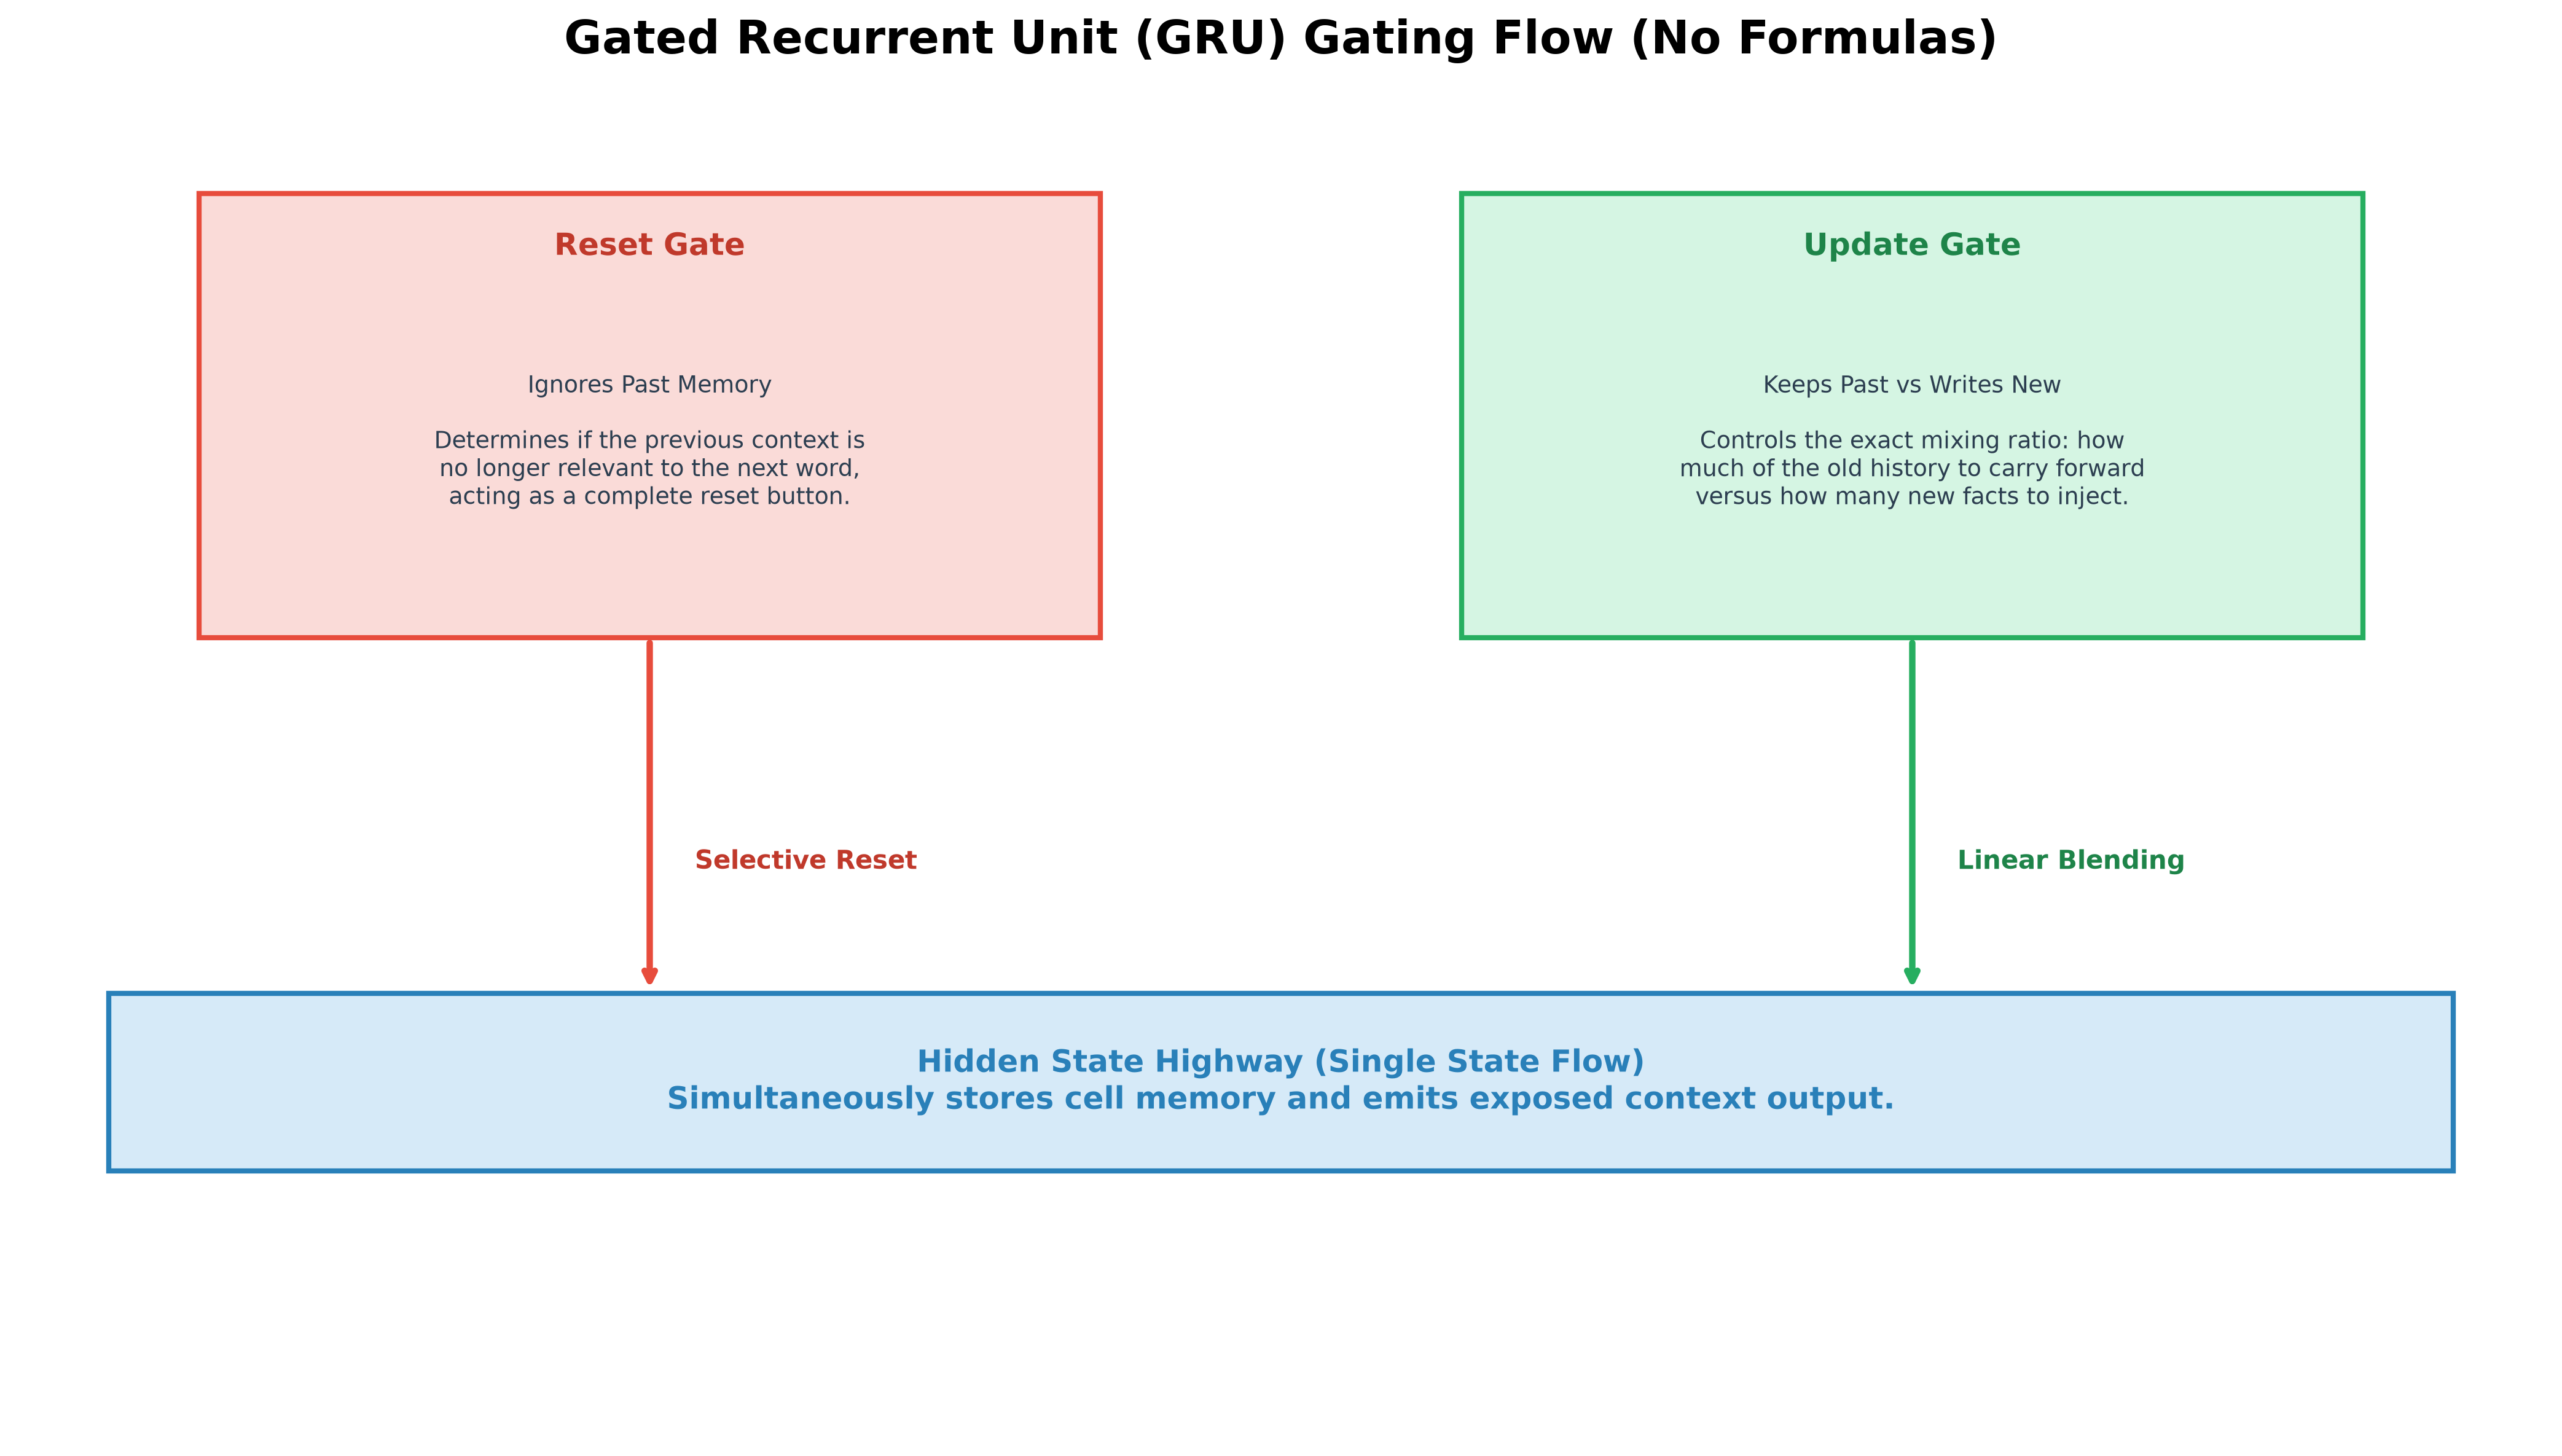


**How information flows in this diagram:**
- Note that there is only one line running along the bottom/middle representing the hidden state $h$.
- The Reset Gate $r_t$ branches off from the hidden state feedback line and multiplies the previous hidden state $h_{t-1}$ before it enters the candidate state ($\tanh$) calculation.
- The Update Gate $z_t$ controls the mixing of the old state $h_{t-1}$ (multiplied by $1-z_t$) and the new candidate state $\tilde{h}_t$ (multiplied by $z_t$).

---

### LSTM vs. GRU: Selection Trade-offs

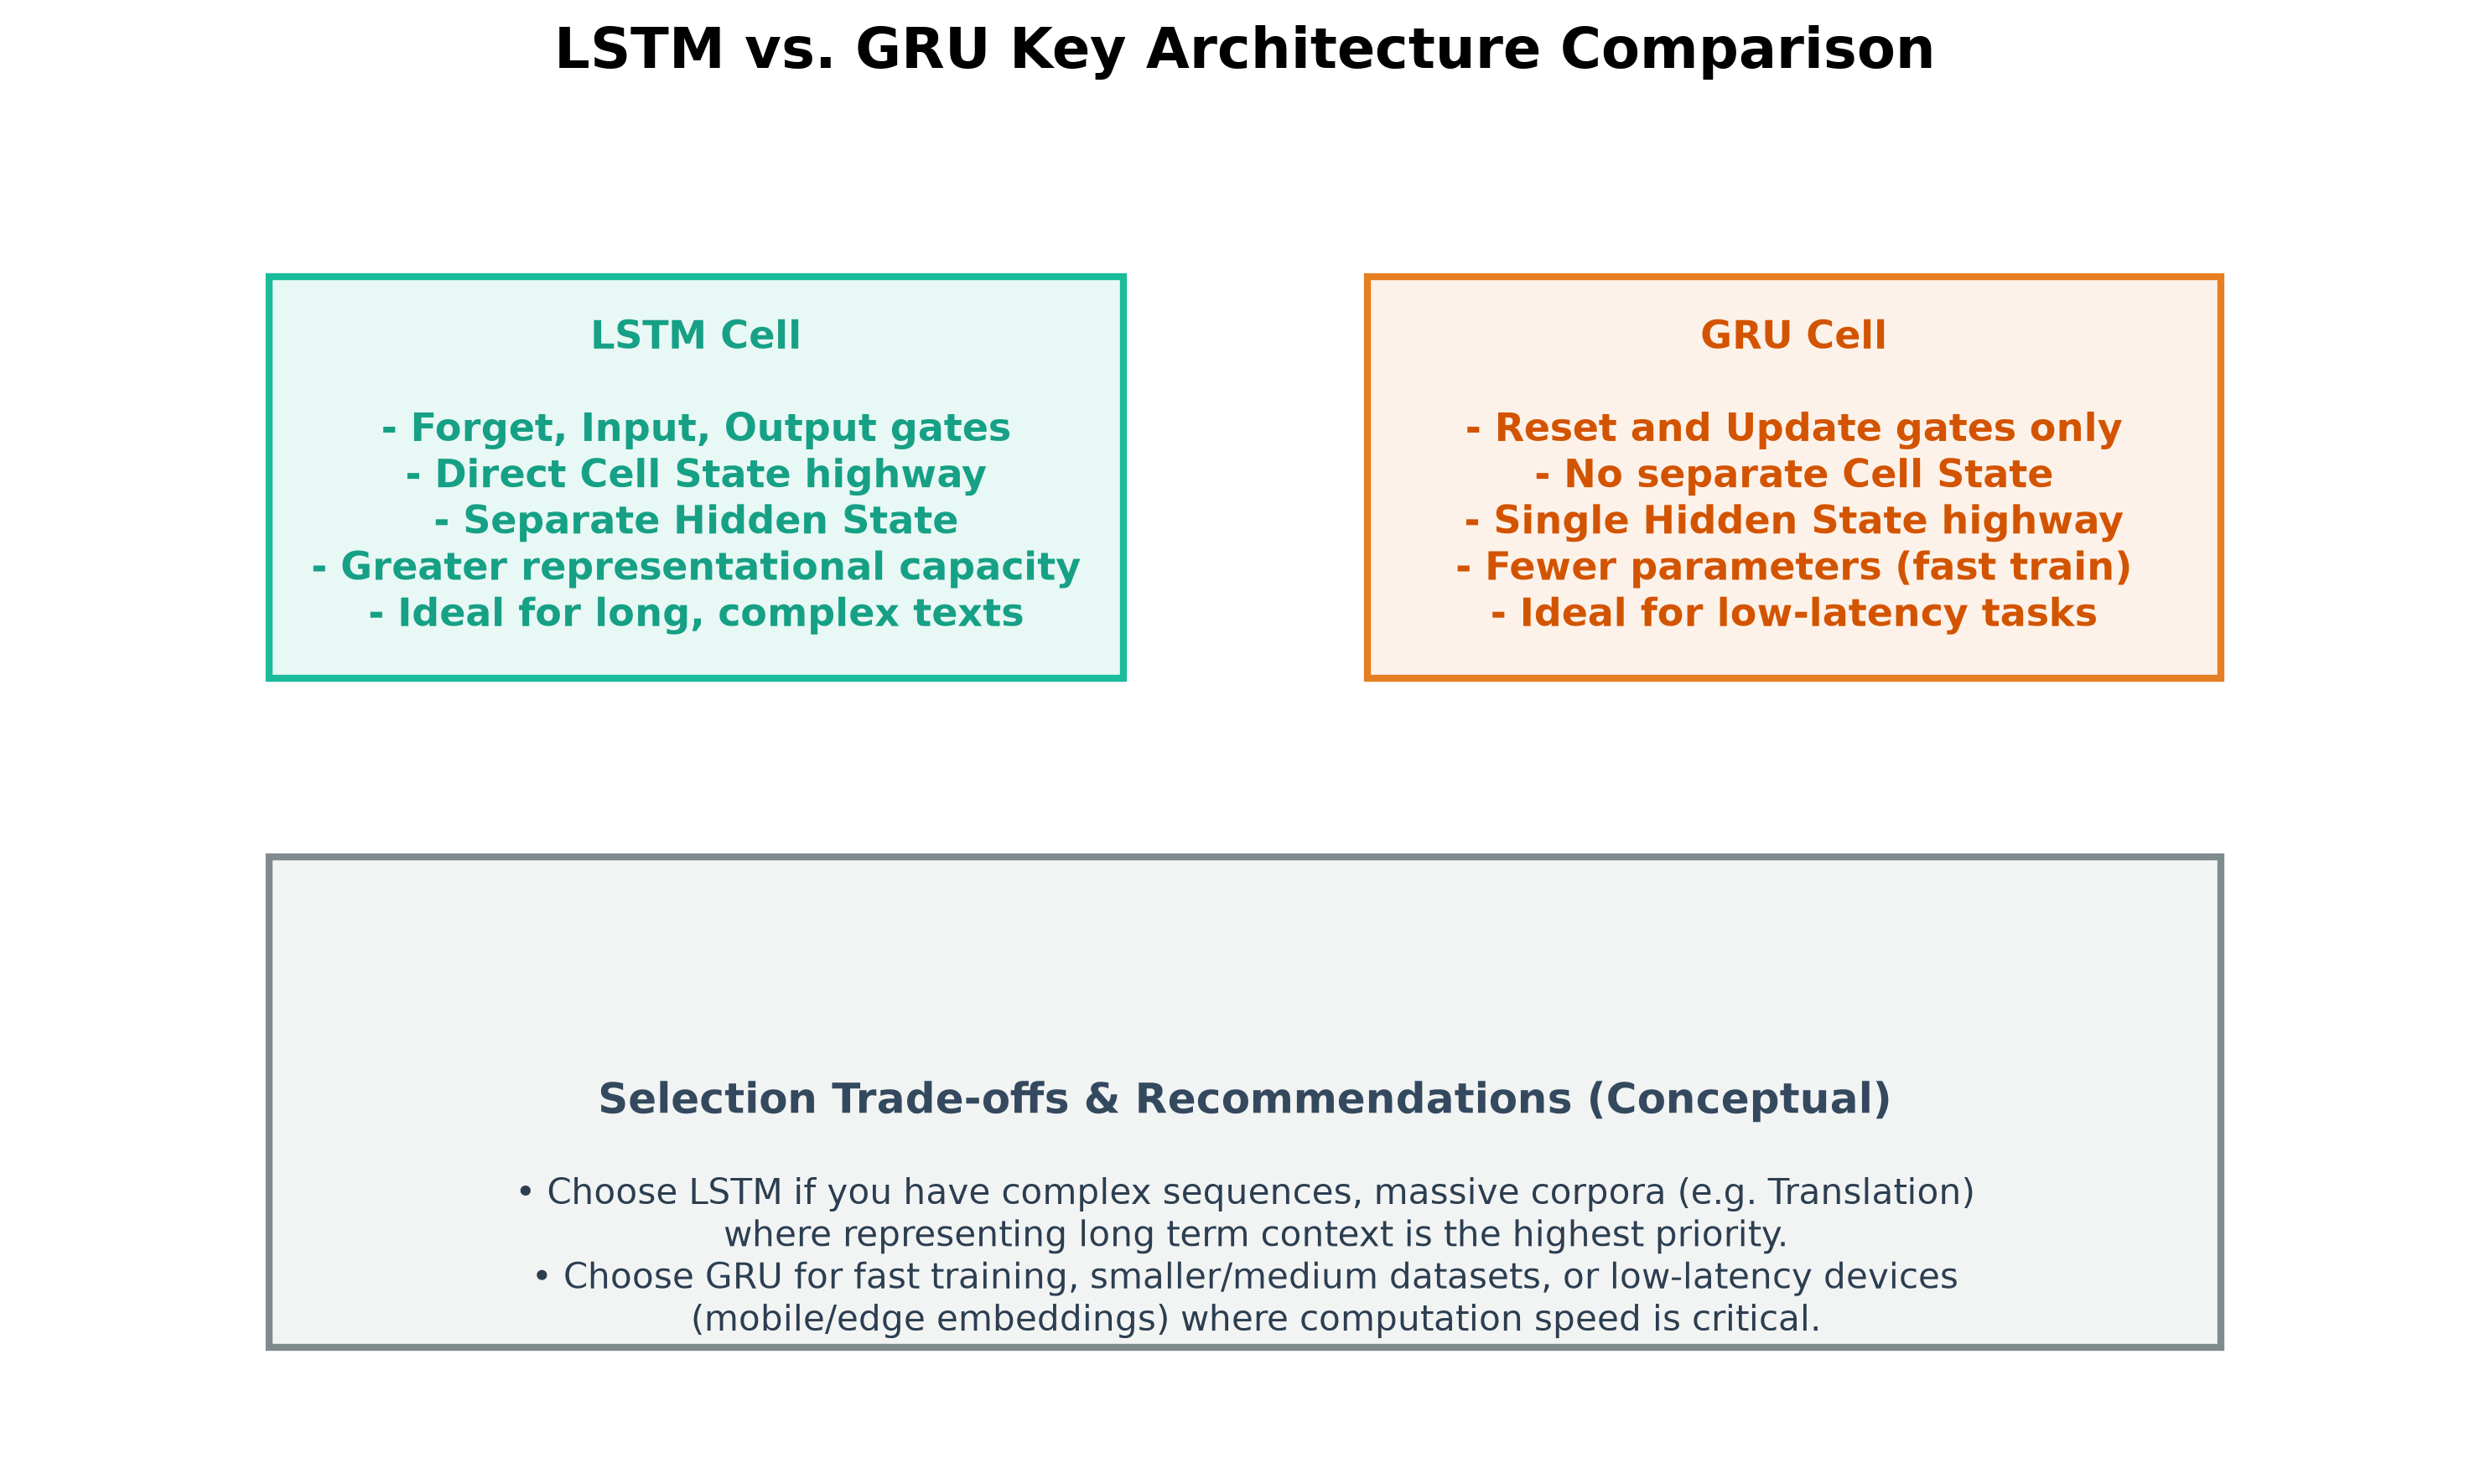


Here is a detailed comparison of when to use which model:

| Metric / Aspect | LSTM (Long Short-Term Memory) | GRU (Gated Recurrent Unit) |
| :--- | :--- | :--- |
| **Complexity** | Higher (3 gates, 2 state vectors: Cell and Hidden) | Lower (2 gates, 1 state vector: Hidden) |
| **Parameter Count** | ~33% more parameters | ~25% fewer parameters than LSTM |
| **Advantages** | - Better at retaining very long-term context.<br>- High representational capacity for large complex datasets. | - Faster to train and requires less memory.<br>- Less prone to overfitting on small/medium datasets. |
| **Disadvantages** | - Slower training and inference latencies.<br>- Prone to overfitting on smaller corpora. | - Slightly lower capacity for complex sequence modeling.<br>- Lack of cell state can make gradient highway less robust. |
| **Best Use Cases** | - Machine translation & complex generative writing.<br>- Large datasets where model capacity is key. | - Latency-sensitive applications (on-device, mobile).<br>- Small or medium datasets with fast training turnarounds. |



### Step 1 — Implement a GRU Cell from Scratch

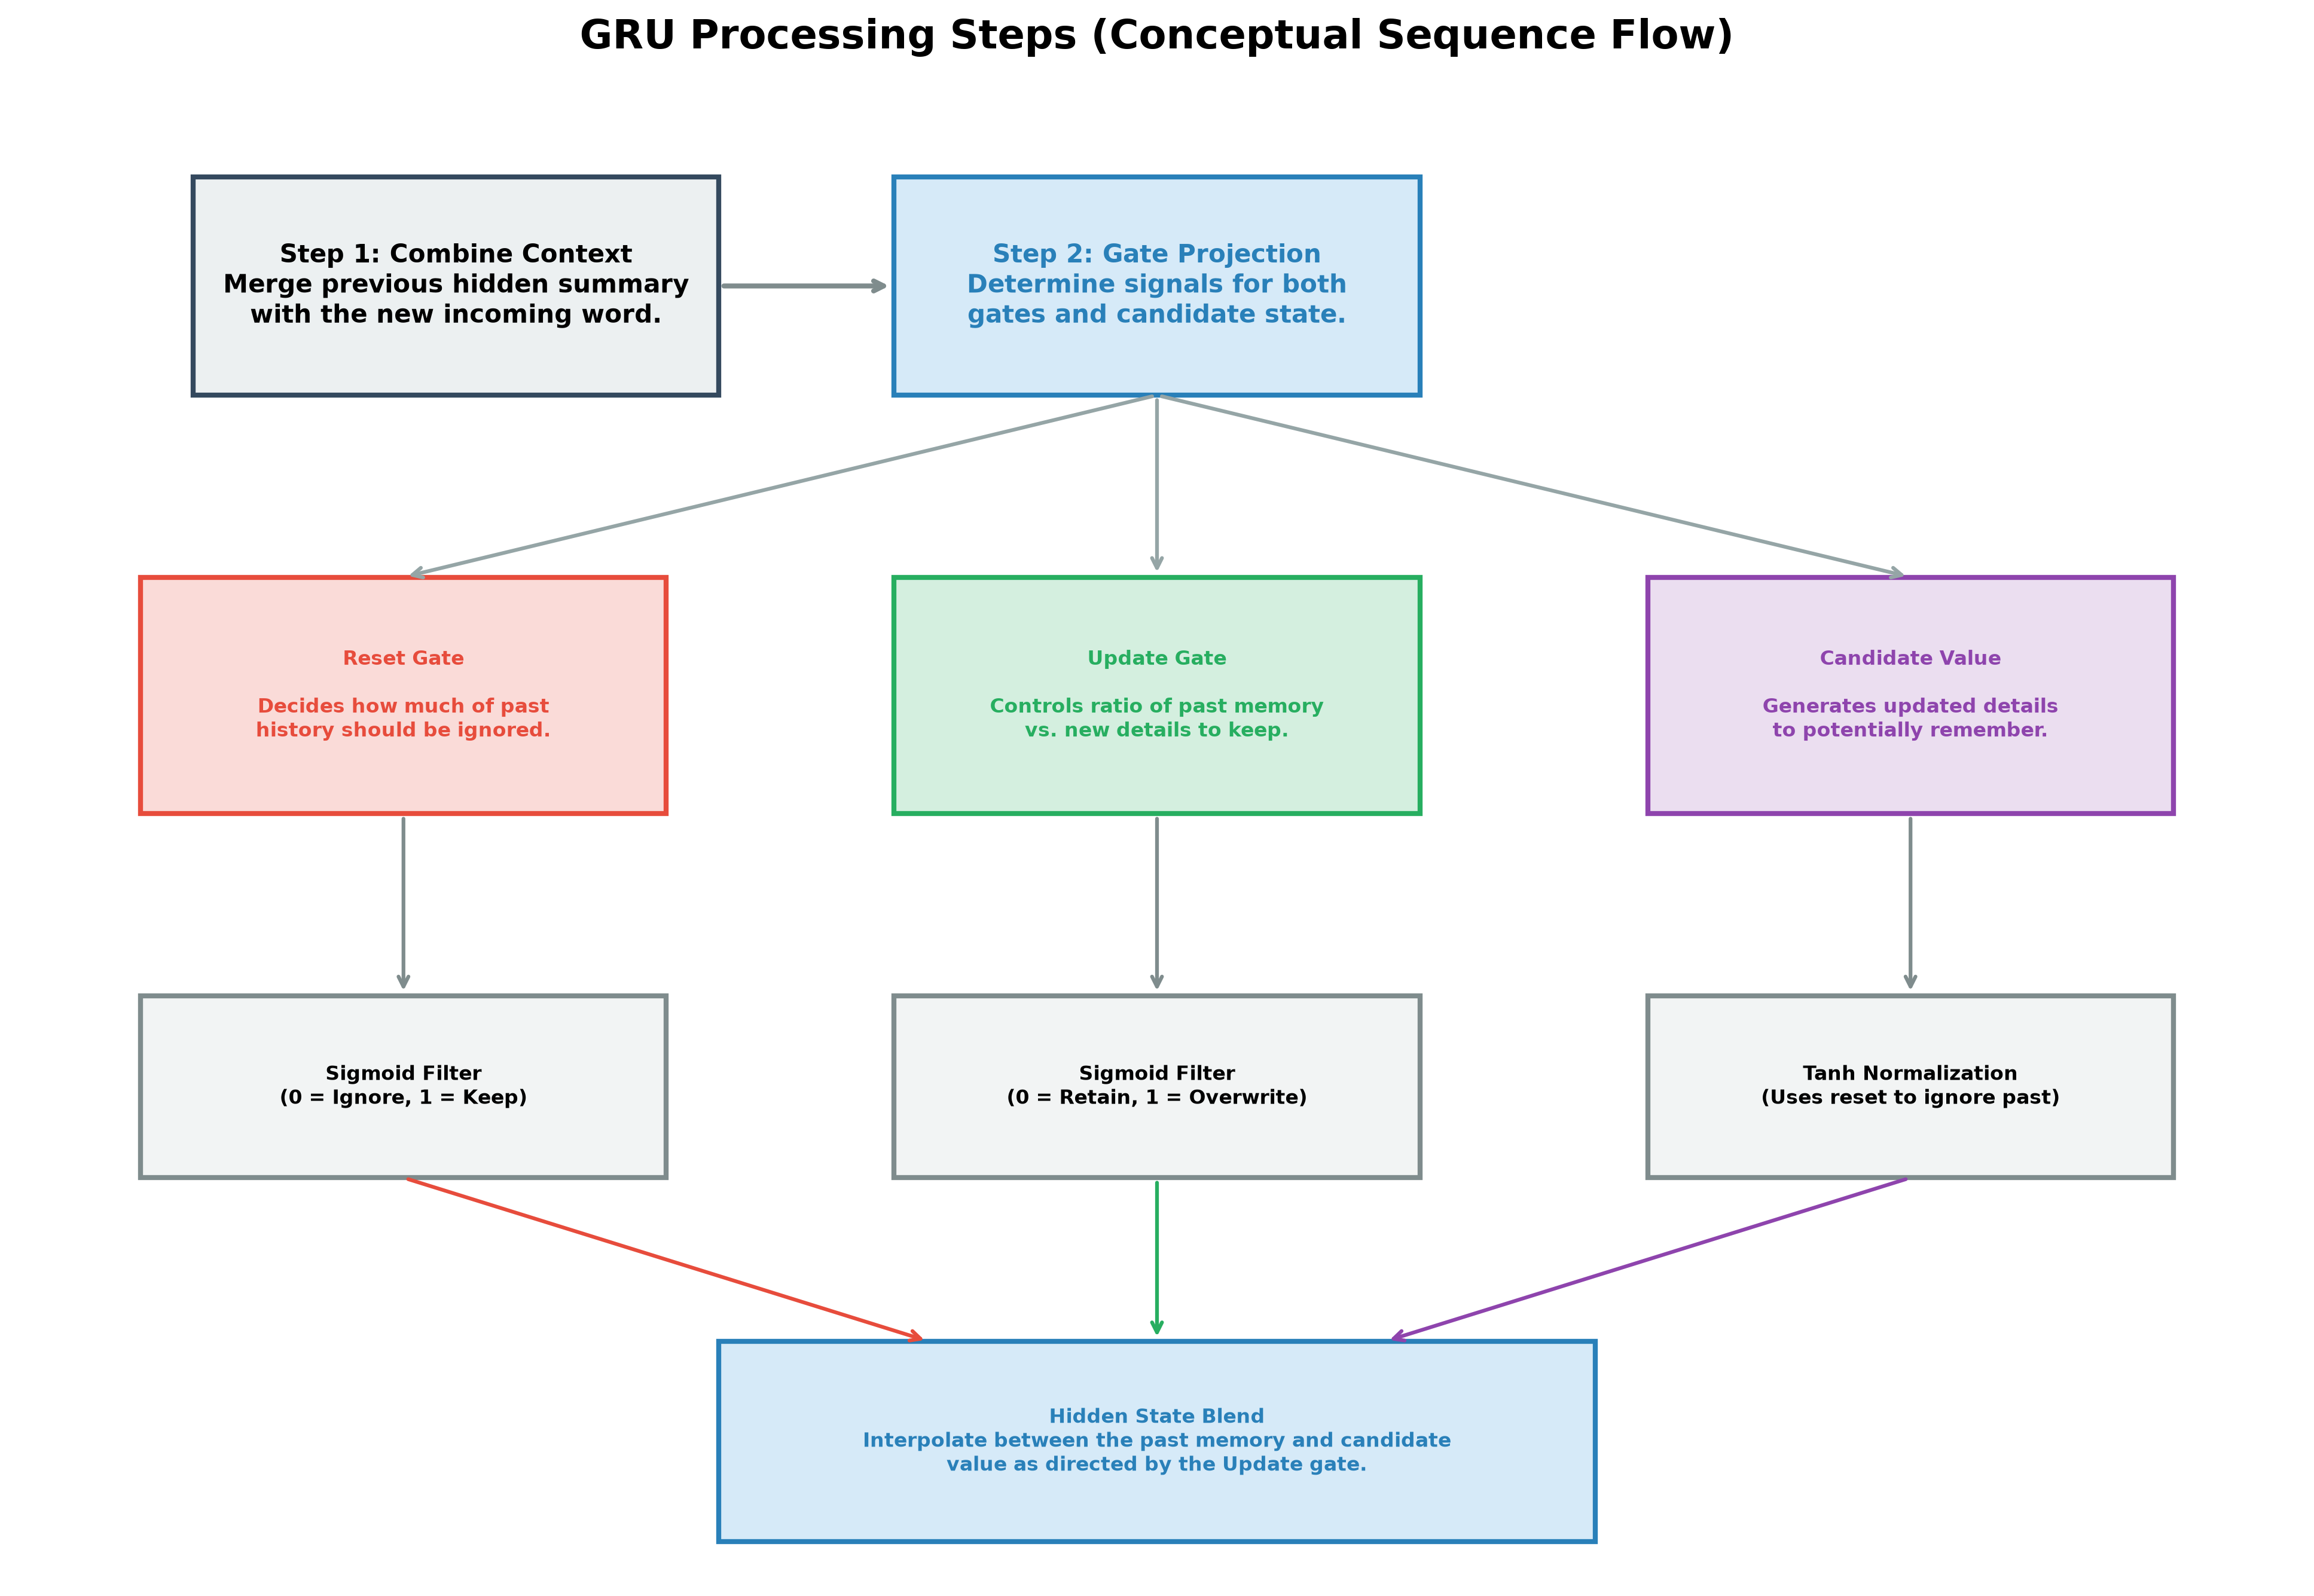



In [1]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

class GRUCellScratch:
    def __init__(self, input_dim, hidden_dim):
        np.random.seed(42)
        self.hidden_dim = hidden_dim
        # Combine weights for gates (reset, update, candidate)
        self.W = np.random.randn(3 * hidden_dim, input_dim + hidden_dim) * 0.1
        self.b = np.zeros((3 * hidden_dim, 1))
        
    def forward(self, x_t, h_prev):
        concat = np.vstack((h_prev, x_t))
        gates = np.dot(self.W, concat) + self.b
        
        r_gate = gates[0:self.hidden_dim]
        z_gate = gates[self.hidden_dim:2*self.hidden_dim]
        
        # Calculate Reset and Update gate activations
        r_t = sigmoid(r_gate)
        z_t = sigmoid(z_gate)
        
        # Calculate Candidate state (using reset gate)
        concat_reset = np.vstack((r_t * h_prev, x_t))
        # Note: self.W_h weights are located in the last slice of self.W
        W_h = self.W[2*self.hidden_dim:]
        b_h = self.b[2*self.hidden_dim:]
        h_tilde = np.tanh(np.dot(W_h, concat_reset) + b_h)
        
        # Calculate final hidden state update
        h_t = (1 - z_t) * h_prev + z_t * h_tilde
        
        return h_t, {
            'reset_gate': r_t,
            'update_gate': z_t,
            'candidate_state': h_tilde
        }

# Instantiate cell
input_dim = 3
hidden_dim = 2
cell = GRUCellScratch(input_dim, hidden_dim)

# Input parameters
x = np.array([[1.0, -0.5, 0.2]]).T
h_p = np.array([[0.1, -0.2]]).T

h_n, gate_vals = cell.forward(x, h_p)

print("GRU Cell Forward Pass Outputs:")
print(f"  Reset Gate Output (r_t)    :\n{gate_vals['reset_gate']}")
print(f"  Update Gate Output (z_t)   :\n{gate_vals['update_gate']}")
print(f"  Candidate Hidden State (~h):\n{gate_vals['candidate_state']}")
print(f"  New Hidden State (h_t)     :\n{h_n}")



GRU Cell Forward Pass Outputs:
  Reset Gate Output (r_t)    :
[[0.49791669]
 [0.51927613]]
  Update Gate Output (z_t)   :
[[0.52249538]
 [0.51579814]]
  Candidate Hidden State (~h):
[[0.07659477]
 [0.07413755]]
  New Hidden State (h_t)     :
[[ 0.08777088]
 [-0.05860036]]


### Step 2 — User-Defined Interactive Evaluation Function
Provide custom values for the inputs and previous states to calculate GRU gate responses dynamically.


In [2]:
def evaluate_gru_gates(input_vals, reset_bias=0.0):
    """
    User-defined evaluation function. Simulates GRU gate logic under custom parameters.
    """
    x_input = np.array([input_vals]).T
    h_p = np.ones((hidden_dim, 1)) * 0.5
    
    temp_cell = GRUCellScratch(len(input_vals), hidden_dim)
    temp_cell.b[0:hidden_dim] += reset_bias
    
    h_n, gates = temp_cell.forward(x_input, h_p)
    
    print(f"--- Evaluation for Input Vector: {input_vals} ---")
    print(f"Reset Bias Offset: {reset_bias}")
    print("-" * 50)
    print(f"Reset Gate values   : {gates['reset_gate'].flatten().round(4)}")
    print(f"Update Gate values  : {gates['update_gate'].flatten().round(4)}")
    print(f"Candidate State (~h): {gates['candidate_state'].flatten().round(4)}")
    print(f"New Hidden State (h): {h_n.flatten().round(4)}")

# Test with high reset bias (keeps previous state context)
evaluate_gru_gates([1.0, 2.0, -1.0], reset_bias=5.0)
print("\n" + "="*60 + "\n")
# Test with low reset bias (resets memory)
evaluate_gru_gates([1.0, 2.0, -1.0], reset_bias=-5.0)



--- Evaluation for Input Vector: [1.0, 2.0, -1.0] ---
Reset Bias Offset: 5.0
--------------------------------------------------
Reset Gate values   : [0.9956 0.9933]
Update Gate values  : [0.4422 0.4781]
Candidate State (~h): [-0.1606 -0.1046]
New Hidden State (h): [0.2079 0.2109]


--- Evaluation for Input Vector: [1.0, 2.0, -1.0] ---
Reset Bias Offset: -5.0
--------------------------------------------------
Reset Gate values   : [0.0101 0.0067]
Update Gate values  : [0.4422 0.4781]
Candidate State (~h): [-0.2195 -0.0537]
New Hidden State (h): [0.1819 0.2353]
